In [1]:
import pandas as pd
import numpy as np
import random as rnd

# import warnings
# warnings.filterwarnings("ignore")

# Importing visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Ensures that graphs are displayed inline in the Jupyter Notebook
# %matplotlib inline

# Importing machine learning algorithms from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import std
from sklearn.model_selection import GridSearchCV

# Data Description

The dataset was found on Kaggle and was related to employee attrition. Different features about employees were provided and whether or not they left the company.

### Dataset columns and descriptions

The dataset contains various numerical, categorical, and numerical values. Some examples of them are as follows:
   1. Numerical: Salary, DailyRate, HourlyRate, etc
   2. Categorical: BusinessTravel, Department, EducationField
   3. Oridnal: RelationshipSatisfcation, WorkLifeBalance (all of which are on a scale of 1-4 or 1-5)

### Data exploration

   1. Explored the shape of the dataframe to get an idea of rows and columns
   2. Checked for null values in the dataframe, no null values so those didn't have to be imputed or otherwise dealt with
   3. Dropped any duplicate rows that may have been present in the dataframe

In [2]:
df = pd.read_csv("HR Employee Attrition.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.loc[df.duplicated()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


# Data Cleaning, Data Preprocessing, and Descriptive Statistics

In [8]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

### Look at the stats of the dataframe

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


### Check for columns that only have 1 unique value in that column

Columns that only have one unique value in the dataframe were dropped

In [10]:
single_unique_cols = [col for col in df.columns if df[col].nunique() == 1]

print(single_unique_cols)



['EmployeeCount', 'Over18', 'StandardHours']


In [11]:
df.drop(single_unique_cols, axis=1, inplace=True)


In [12]:
double_unique_cols = [col for col in df.columns if df[col].nunique() == 2]

print(double_unique_cols)

['Attrition', 'Gender', 'OverTime', 'PerformanceRating']


In [13]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBalance                4
YearsAtCompany                37
YearsInCurrentRole            19
YearsSince

### Remove columns that only have one unique value or don't contribute


In [14]:
df[["OverTime", 'Attrition']].groupby(['Attrition'], as_index=False).mean()



C:\Users\nicol\AppData\Local\Temp\ipykernel_20912\3089037361.py:1: FutureWarning: Dropping invalid columns in DataFrameGroupBy.mean is deprecated. In a future version, a TypeError will be raised. Before calling .mean, select only columns which should be valid for the function.
  df[["OverTime", 'Attrition']].groupby(['Attrition'], as_index=False).mean()


,Attrition
0,No
1,Yes


### Separate out categorical values from dataset

I wanted to look at the ordinial variable with the categorical variables so I seperated categorical and numerical values accordingly.

In [15]:

cat_df = df[['Attrition','BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Education',
             'EnvironmentSatisfaction','JobInvolvement', 'JobSatisfaction','PerformanceRating','RelationshipSatisfaction',
            'WorkLifeBalance']]
cat_df

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes,2,2,3,4,3,1,1
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No,1,3,2,2,4,4,3
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes,2,4,2,3,3,2,3
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes,4,4,3,3,3,3,3
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No,1,1,3,2,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No,2,3,4,4,3,3,3
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No,1,4,2,1,3,1,3
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes,3,2,4,2,4,2,3
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No,3,4,2,2,3,4,2


### Get counts for attrition column

In [16]:
df['Attrition'].value_counts()

No     1233
Yes     237
Name: Attrition, dtype: int64

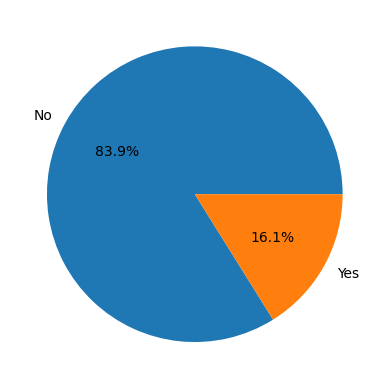

In [17]:
plt.pie(df['Attrition'].value_counts(), autopct='%1.1f%%', labels=['No', 'Yes'] )
plt.show()

### Create dataframe of numerical columns

Created a dataframe for the numerical values


In [18]:
num_df = df[['Attrition','Age', 'DailyRate','DistanceFromHome', 'HourlyRate', 'MonthlyIncome','MonthlyRate','NumCompaniesWorked',
            'PercentSalaryHike','TotalWorkingYears', 'TrainingTimesLastYear','YearsAtCompany', 'YearsInCurrentRole',
            'YearsSinceLastPromotion', 'YearsWithCurrManager']]

### Look at distribution for all numerical columns

Created a histogram to look at the distribution of the numerical columns

C:\Users\nicol\AppData\Local\Temp\ipykernel_20912\2091366175.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


<Figure size 640x480 with 0 Axes>

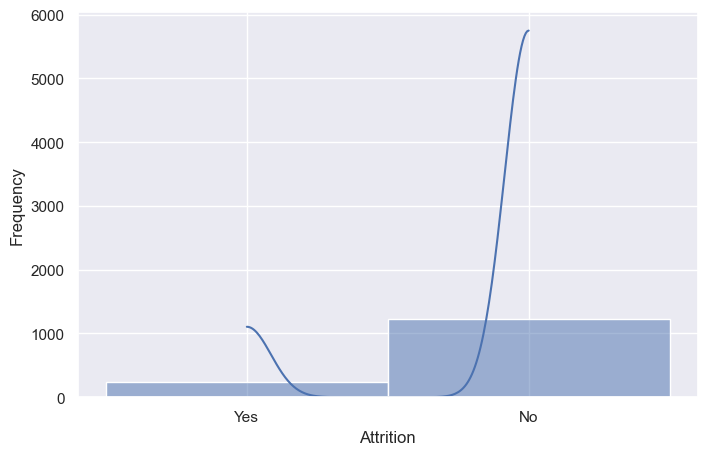

<Figure size 800x500 with 0 Axes>

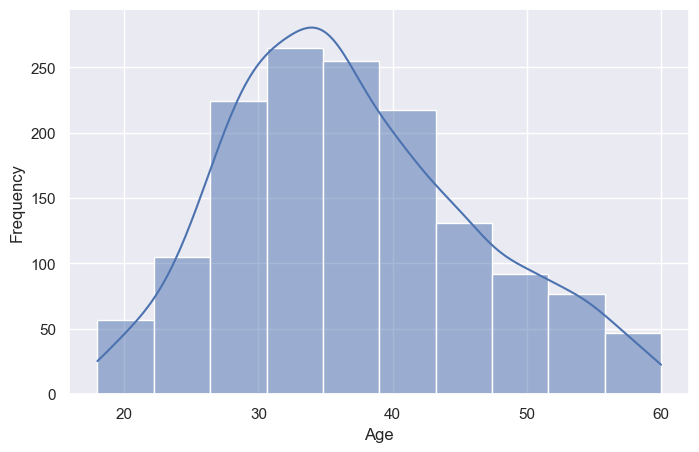

<Figure size 800x500 with 0 Axes>

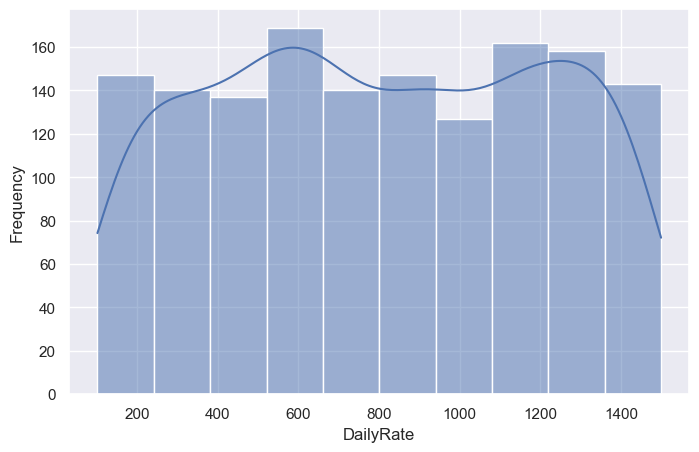

<Figure size 800x500 with 0 Axes>

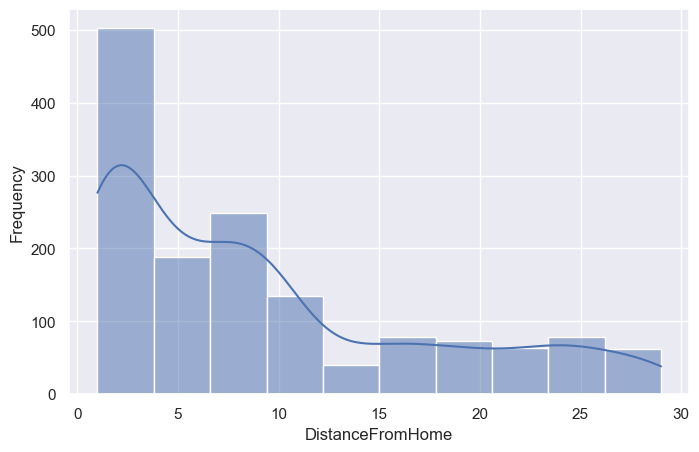

<Figure size 800x500 with 0 Axes>

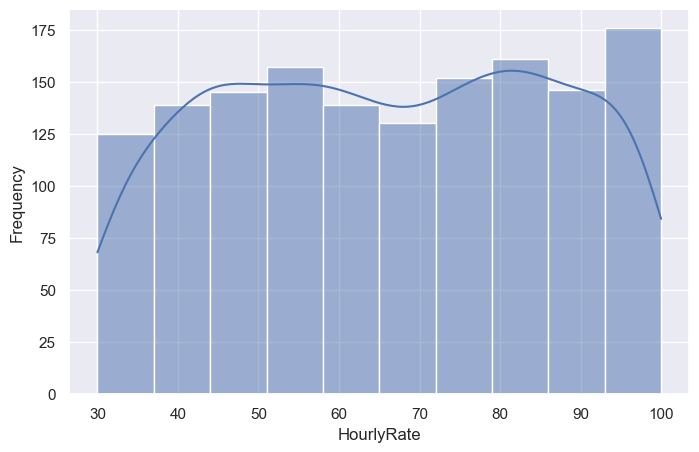

<Figure size 800x500 with 0 Axes>

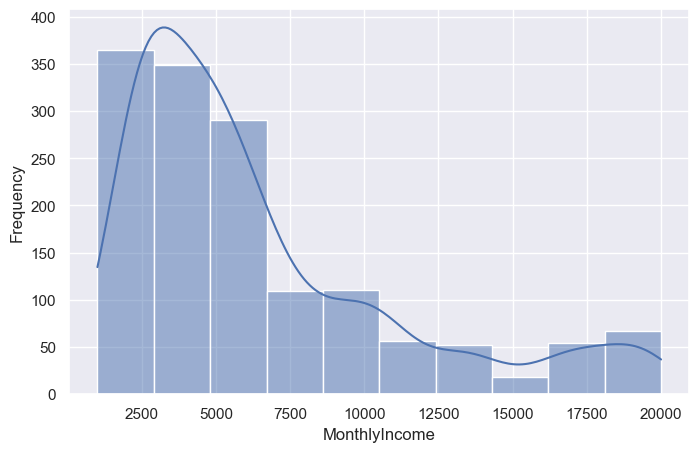

<Figure size 800x500 with 0 Axes>

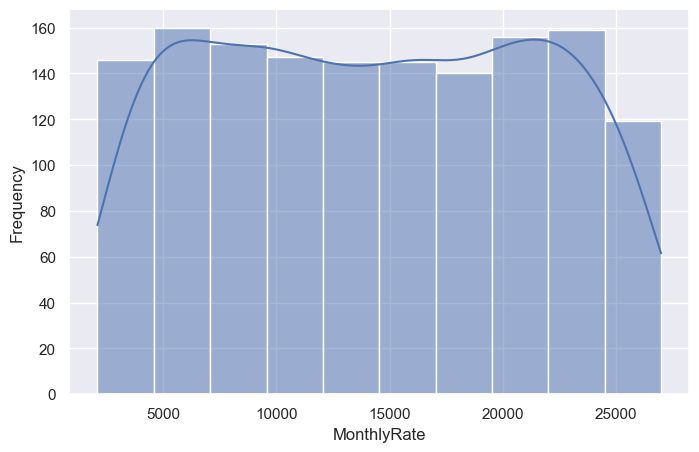

<Figure size 800x500 with 0 Axes>

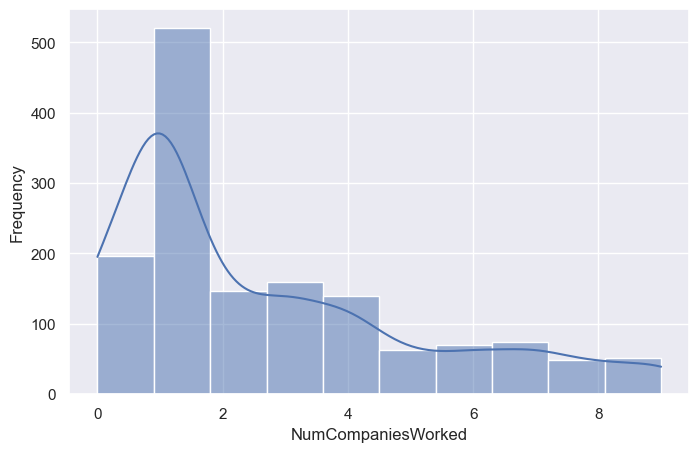

<Figure size 800x500 with 0 Axes>

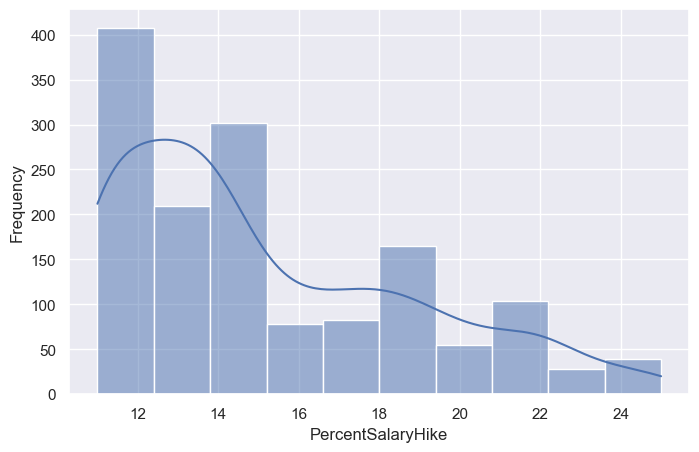

<Figure size 800x500 with 0 Axes>

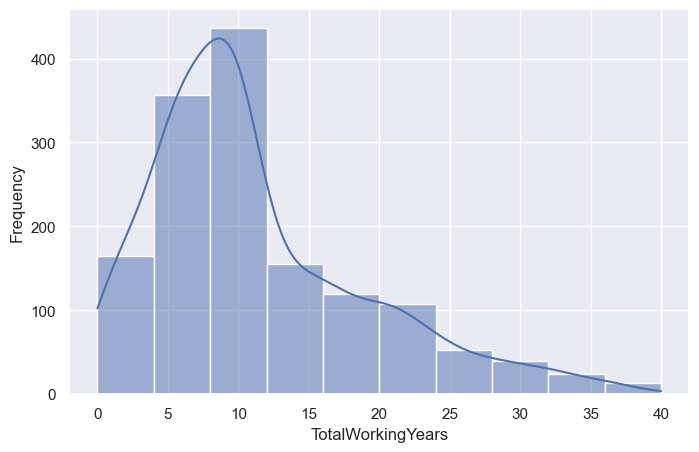

<Figure size 800x500 with 0 Axes>

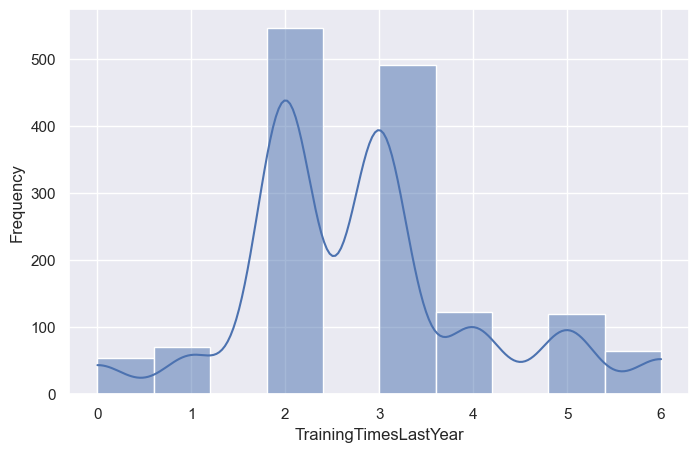

<Figure size 800x500 with 0 Axes>

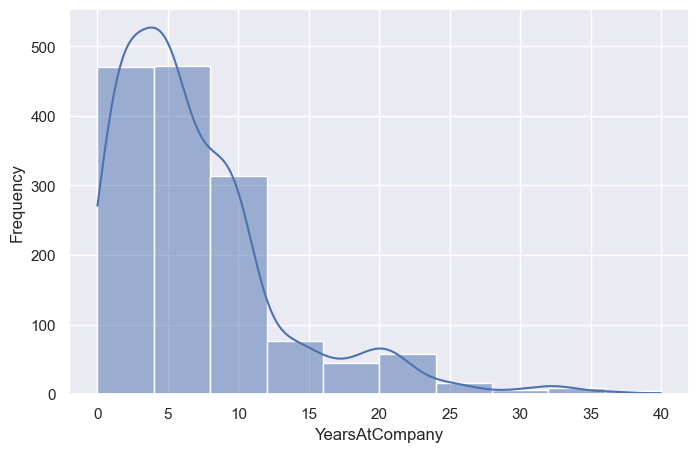

<Figure size 800x500 with 0 Axes>

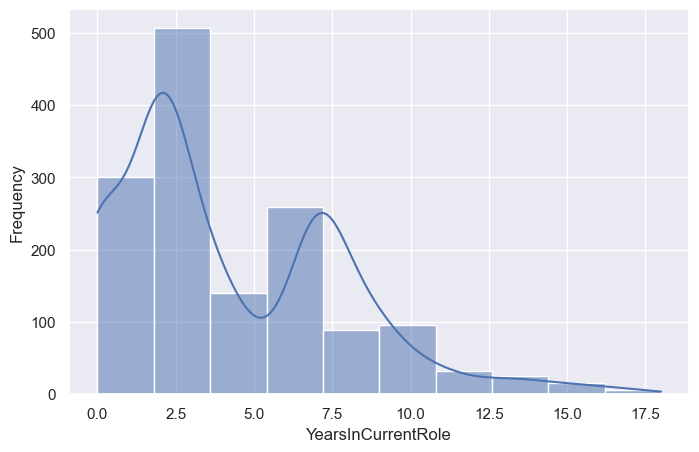

<Figure size 800x500 with 0 Axes>

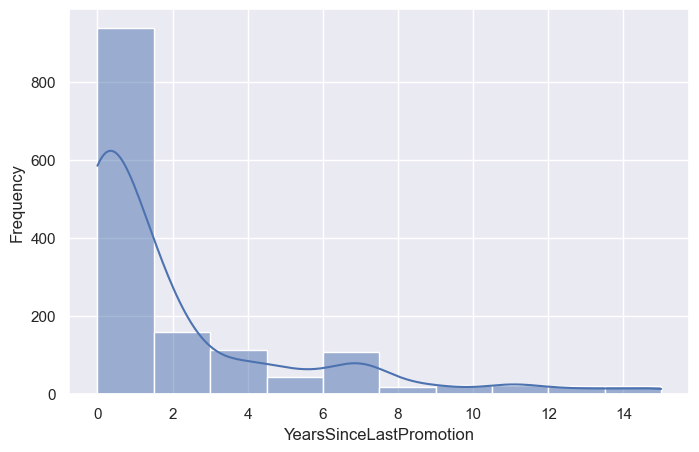

<Figure size 800x500 with 0 Axes>

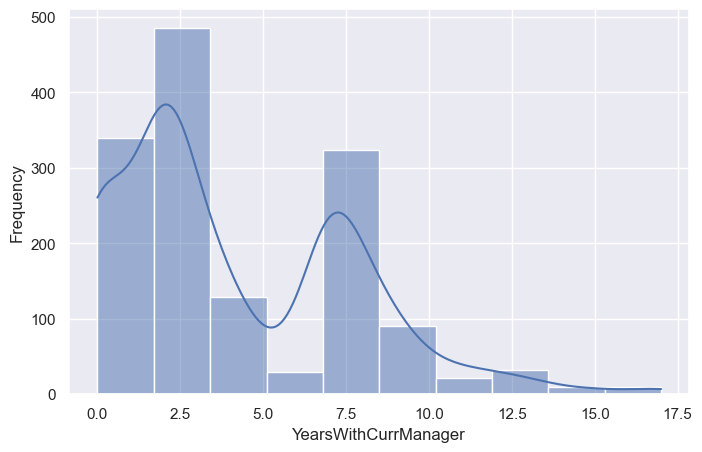

In [19]:
for i in num_df.columns:
    plt.figure()
    plt.tight_layout()
    sns.set(rc={"figure.figsize":(8, 5)})
    f, ax_hist = plt.subplots(1, sharex=True)
    plt.gca().set(xlabel= i,ylabel='Frequency')
    
    sns.histplot(df[i], ax=ax_hist , bins = 10,kde=True)
    



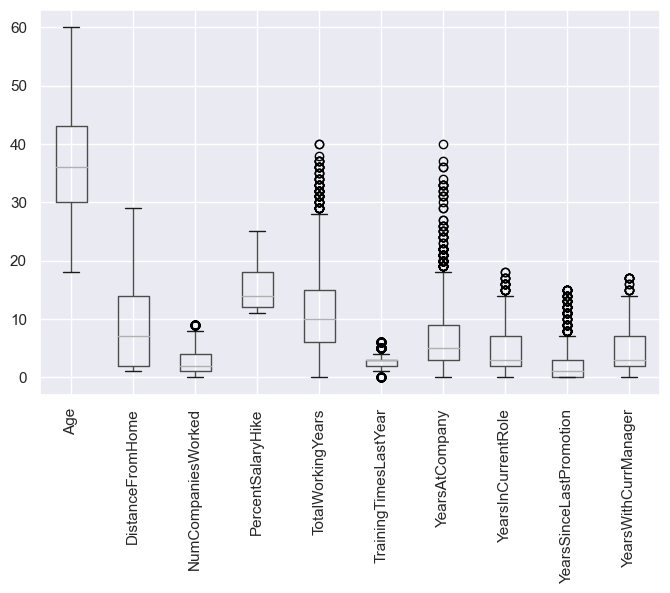

In [20]:
num_df.boxplot(column=['Age','DistanceFromHome','NumCompaniesWorked',
            'PercentSalaryHike','TotalWorkingYears', 'TrainingTimesLastYear','YearsAtCompany', 'YearsInCurrentRole',
            'YearsSinceLastPromotion', 'YearsWithCurrManager'])


plt.xticks(rotation = 90)
plt.show()

### Look at distribution for categorical columns

Looked at the distributions of the categorical columns

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


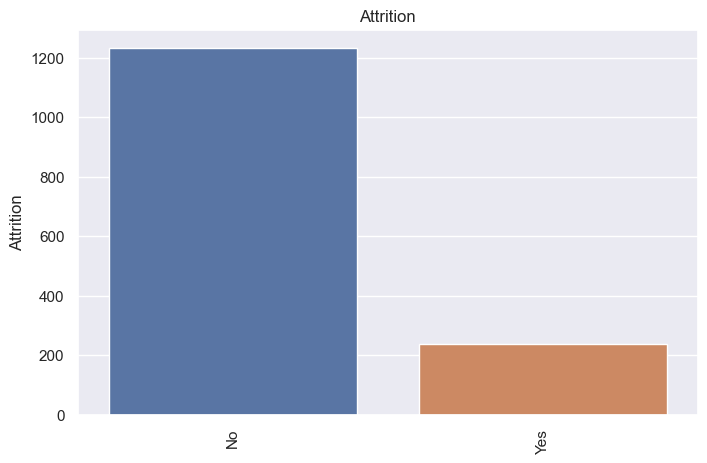

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


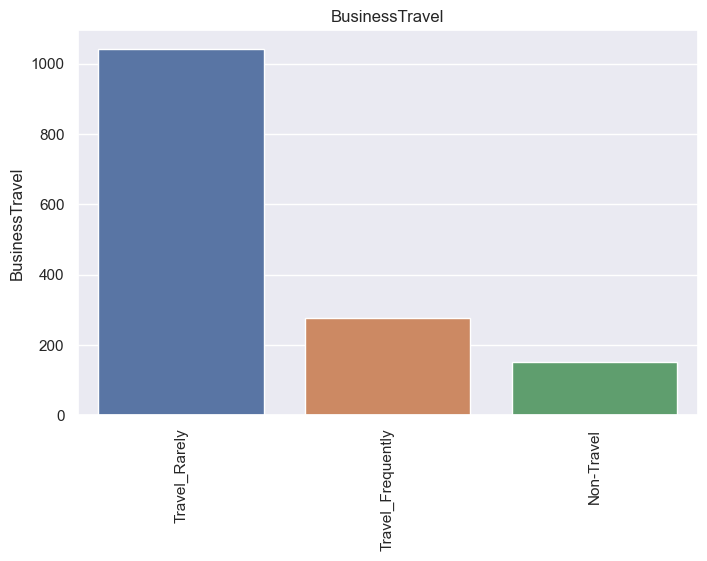

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


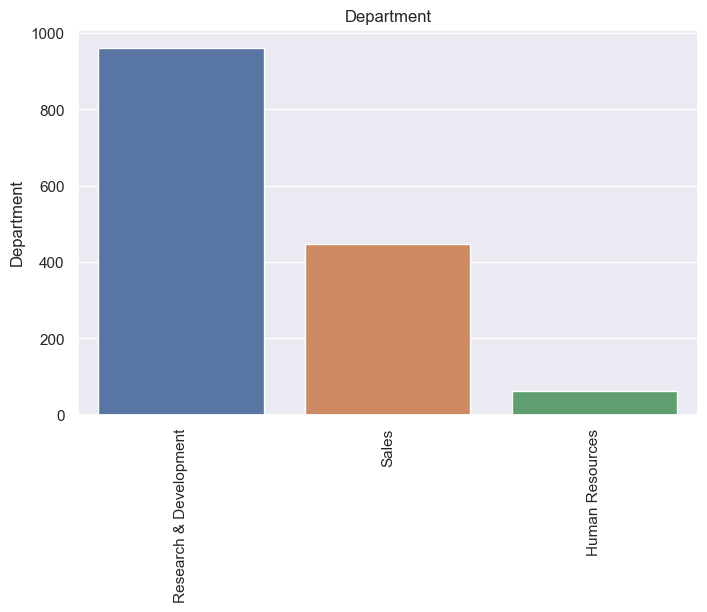

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


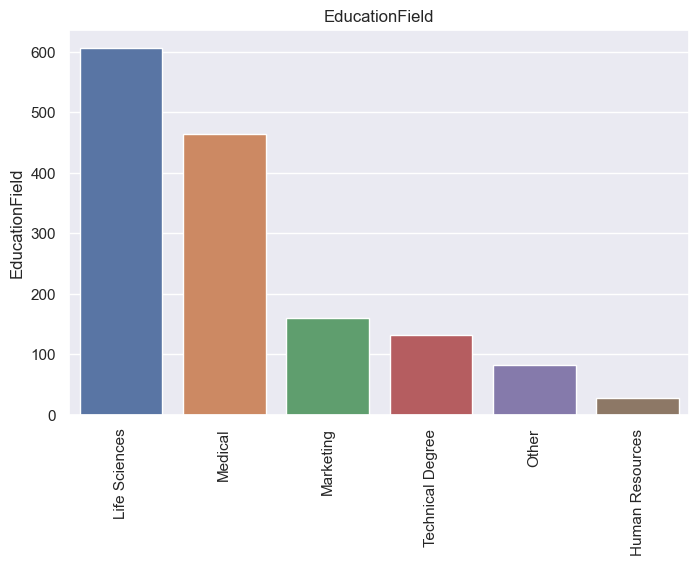

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


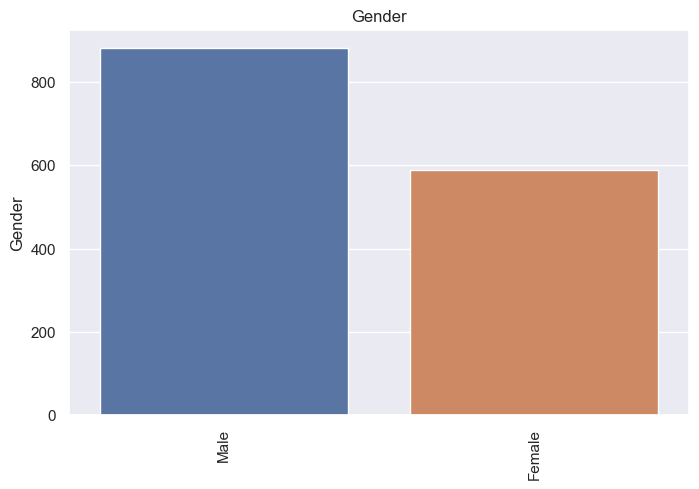

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


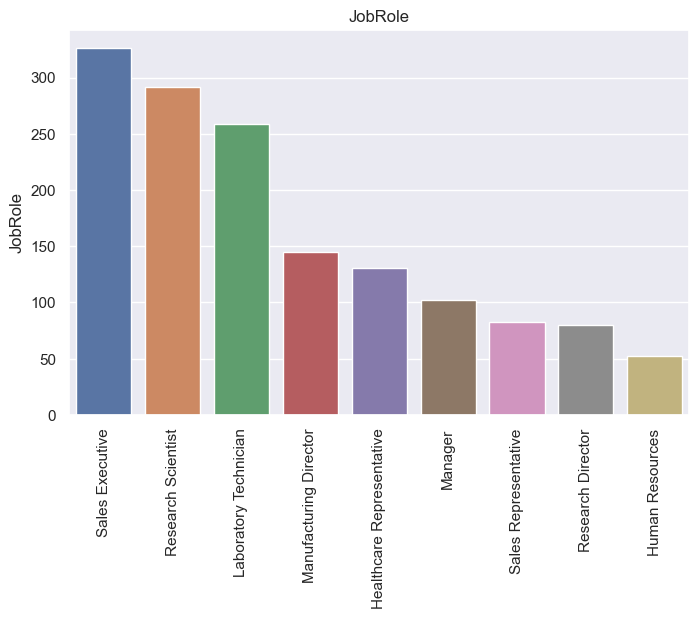

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


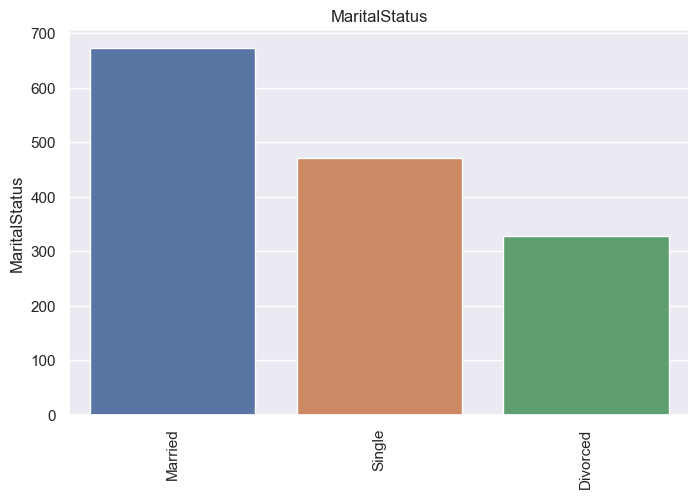

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


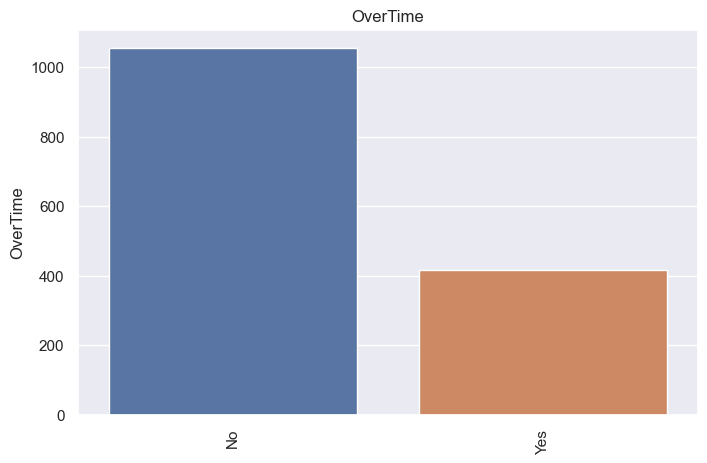

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


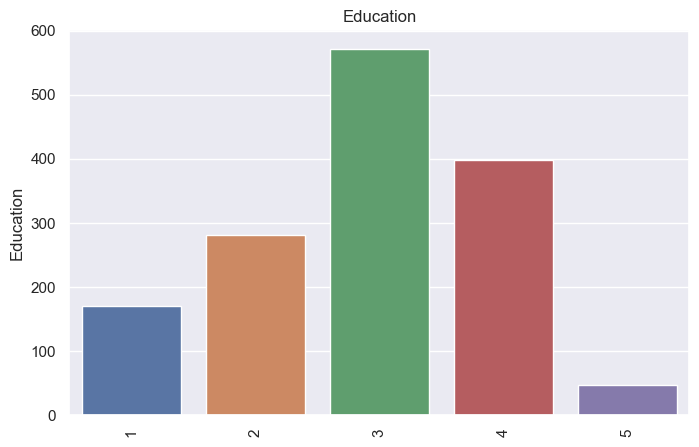

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


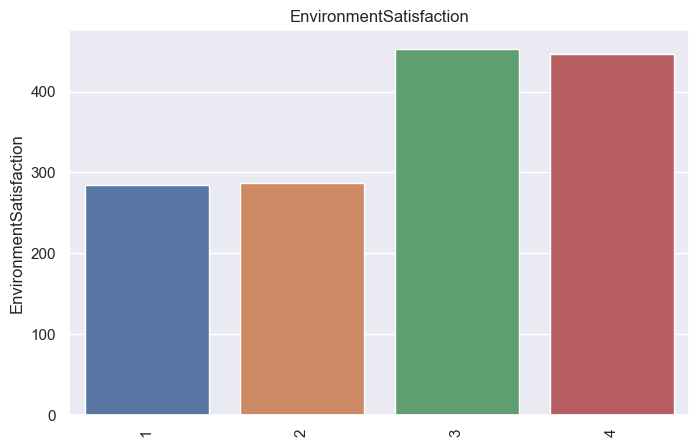

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


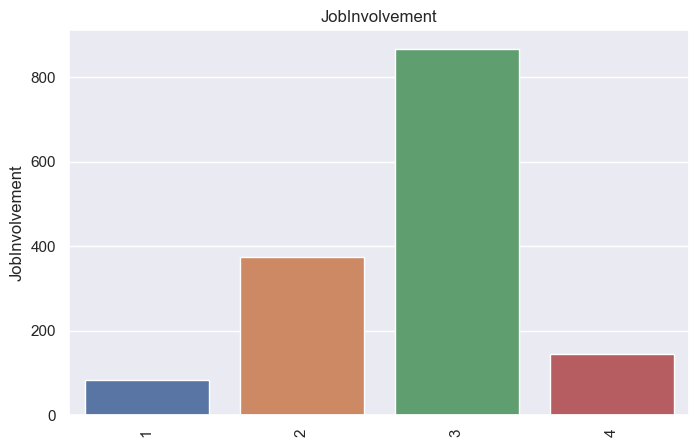

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


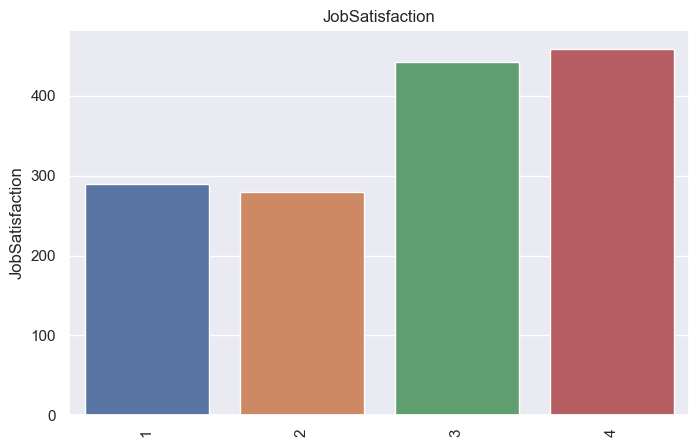

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


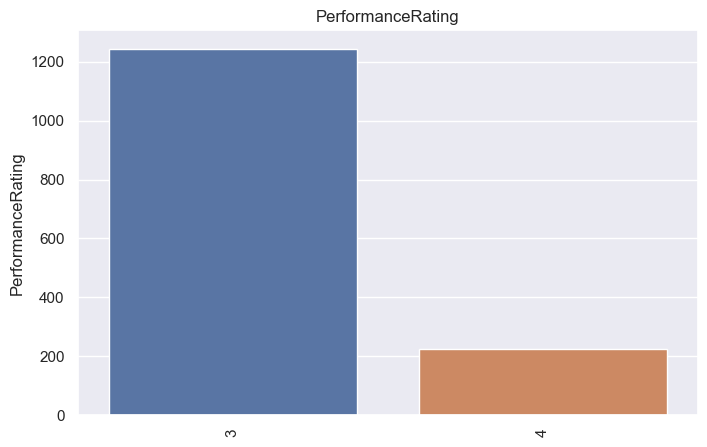

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


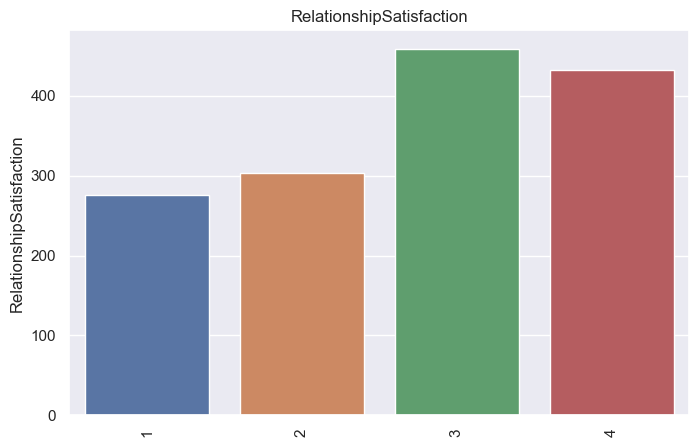

C:\Users\nicol\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


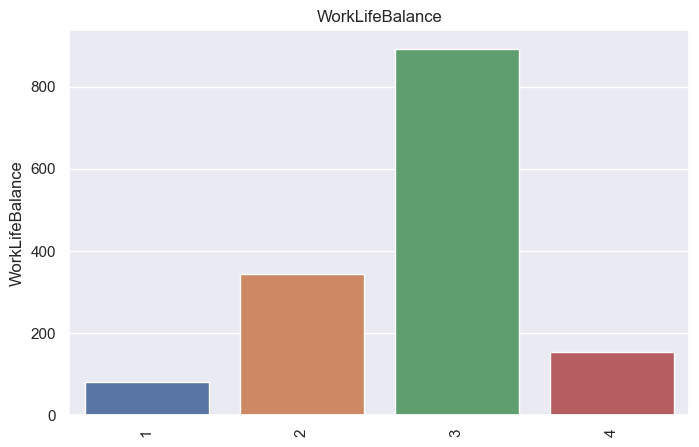

In [21]:
# find better way to show these graphs
for i in cat_df.columns:
#     put variables in here
    sns.barplot(cat_df[i].value_counts().index,cat_df[i].value_counts()).set_title(i)
    plt.xticks(rotation = 90)
    plt.show()

### Compared the count to see relatioship between different categorical features and whether or not there was attrition

Based on the countplot, overtime immediately stands out as a possible contributing factor to attrition

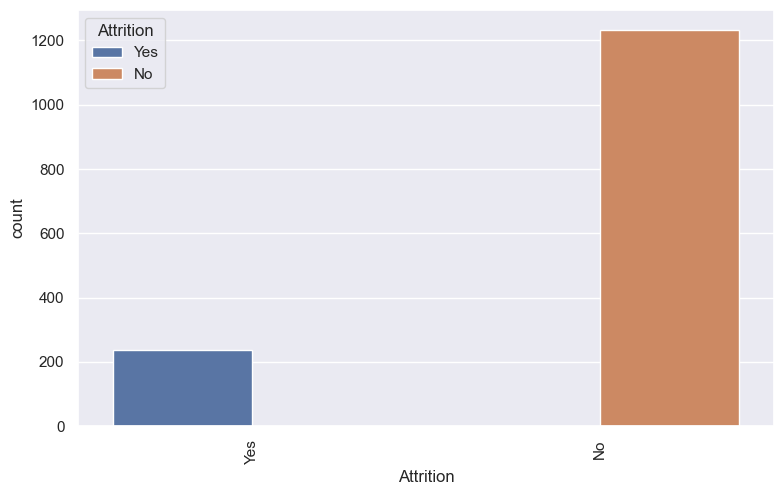

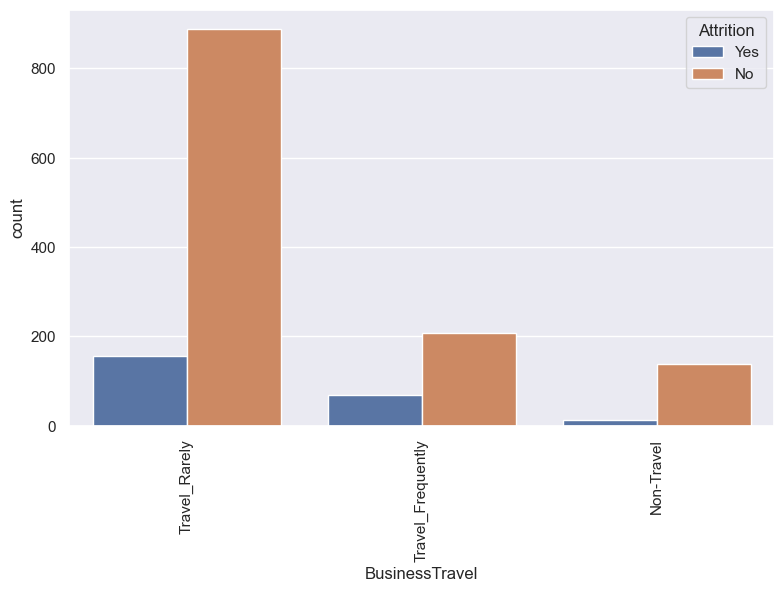

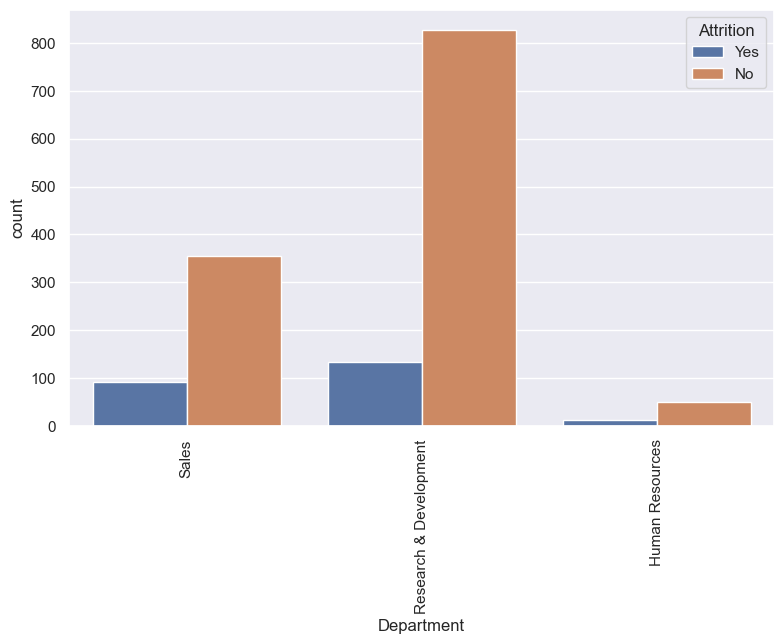

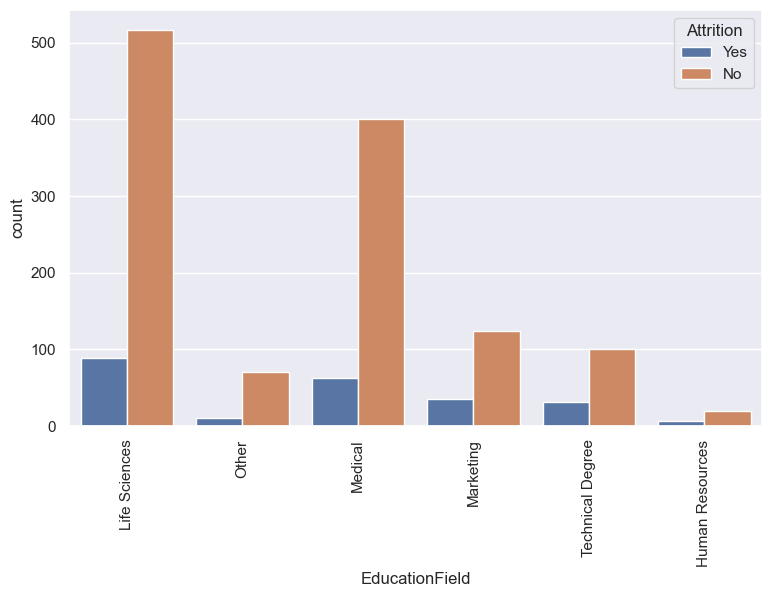

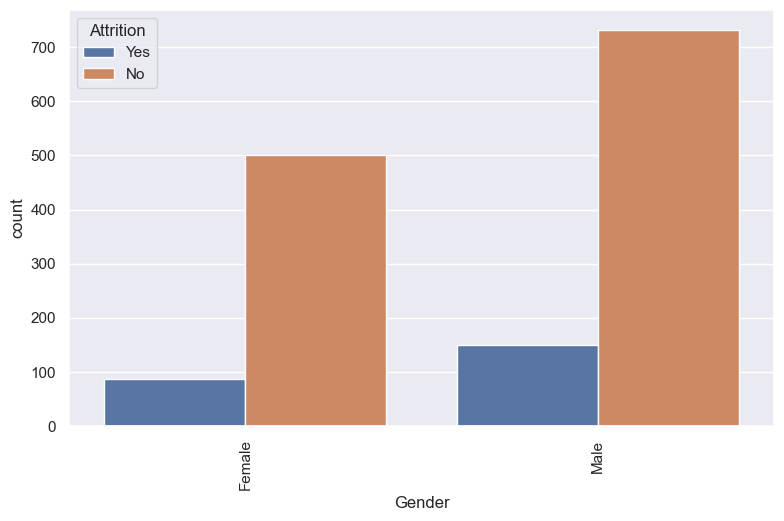

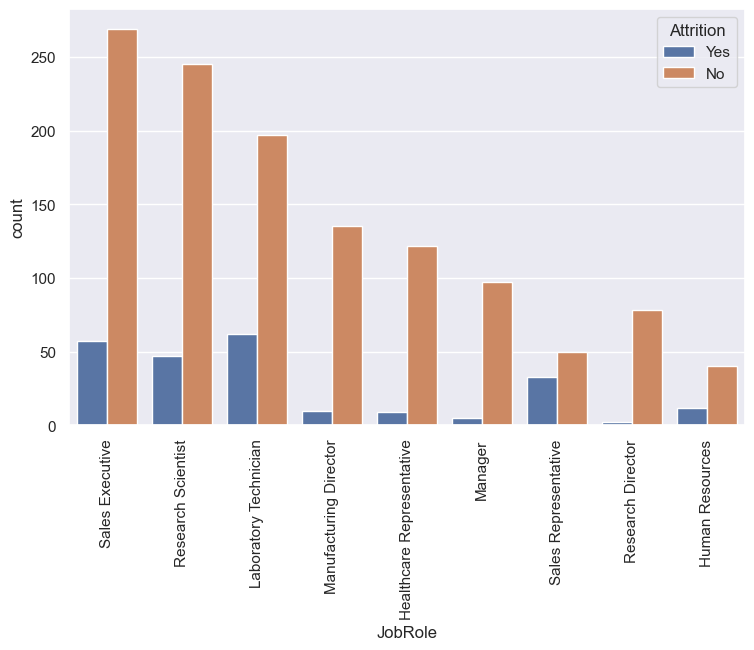

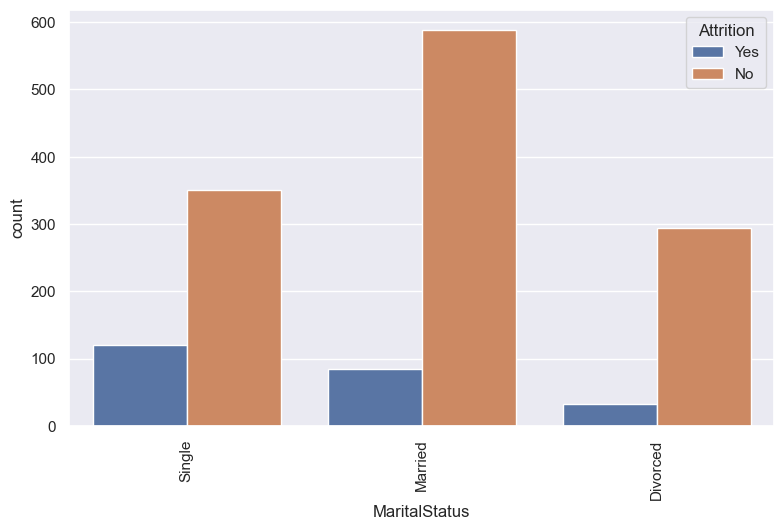

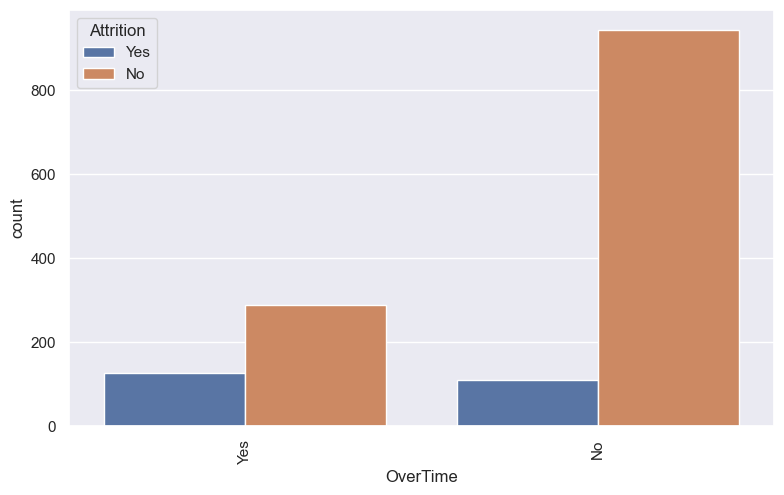

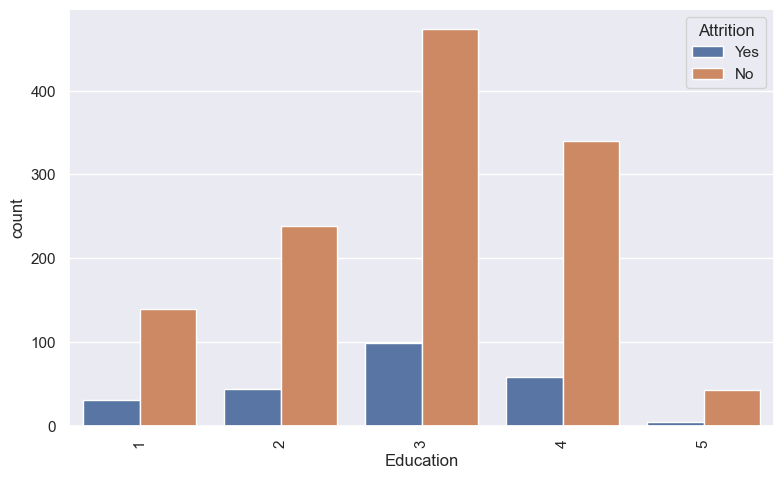

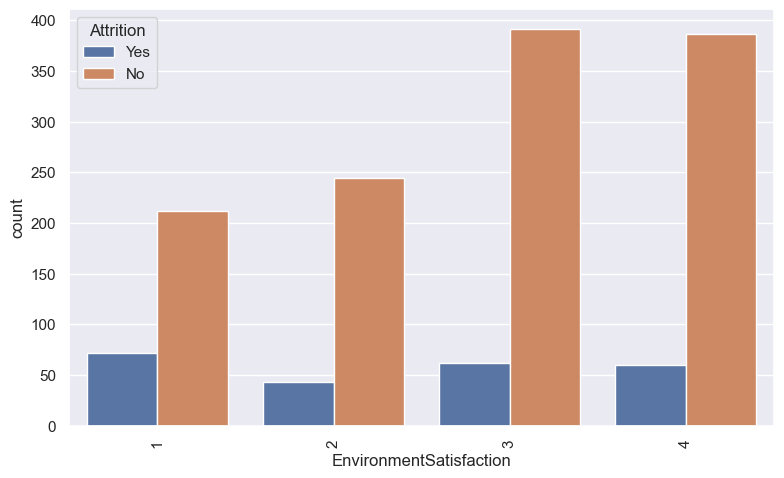

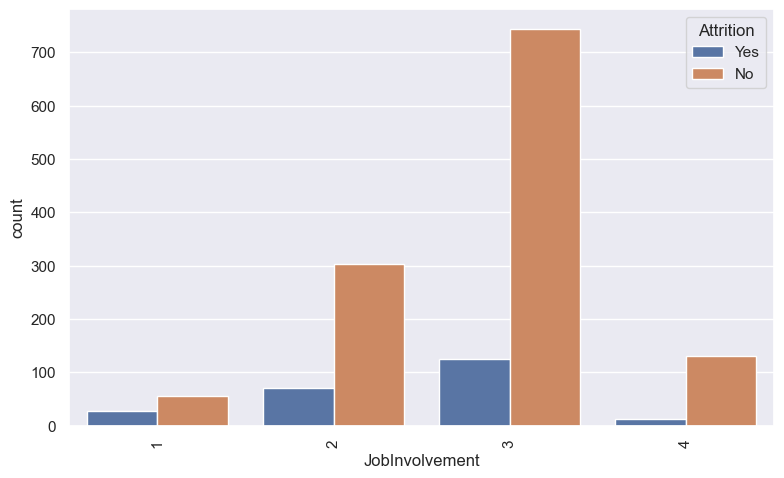

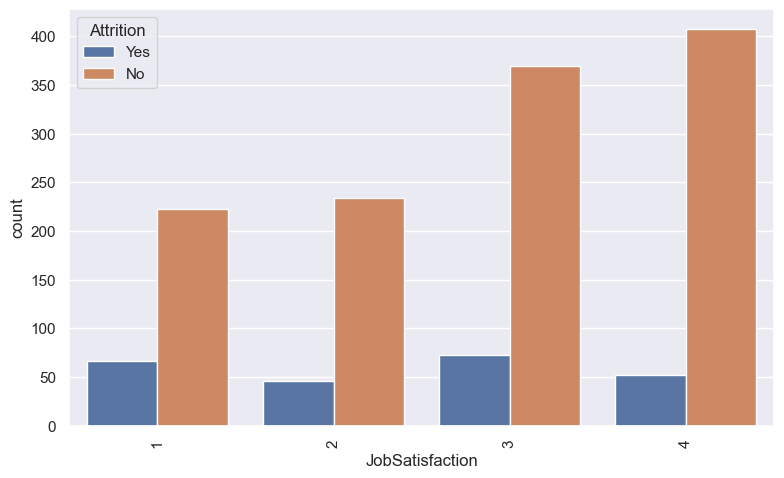

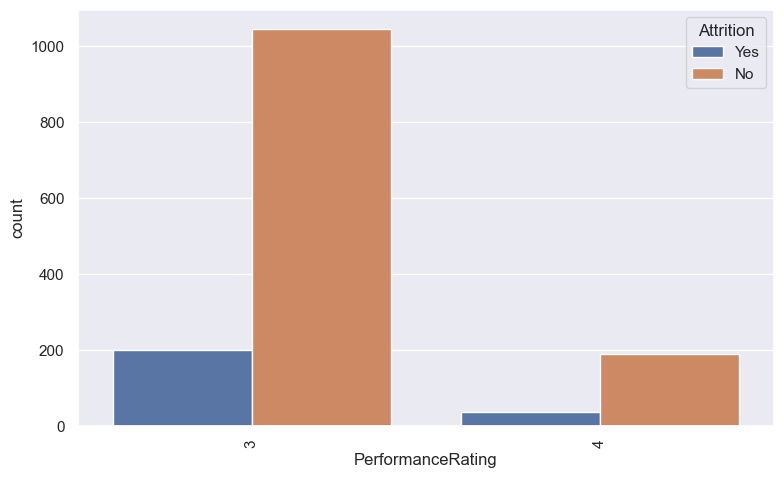

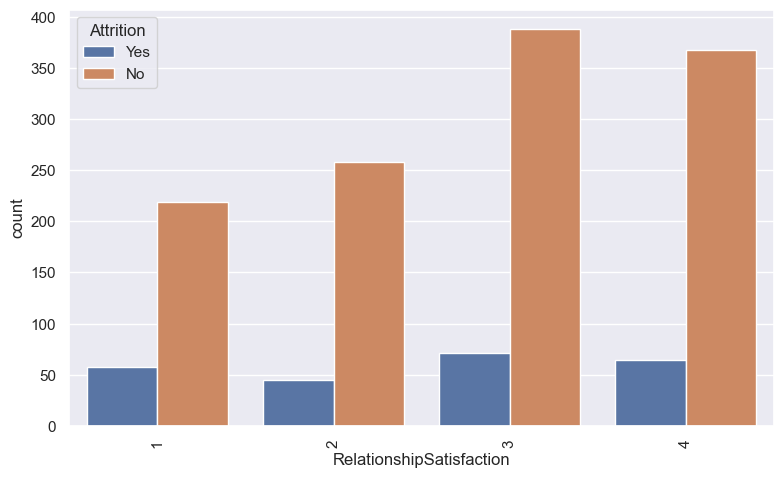

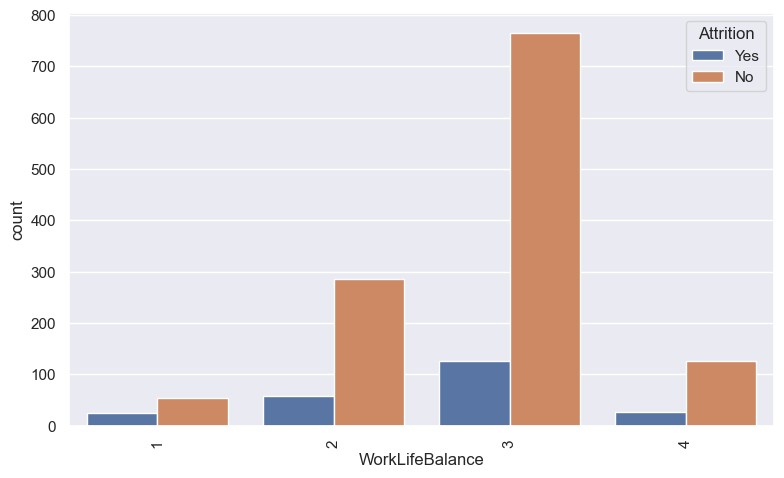

In [22]:
for i in cat_df.columns:
    sns.countplot(data=cat_df, x=i, hue='Attrition')
    plt.tight_layout()
    plt.xticks(rotation = 90)
    plt.show()

### Heatmap
- Created a heatmap to see possible correlations between the numeric features

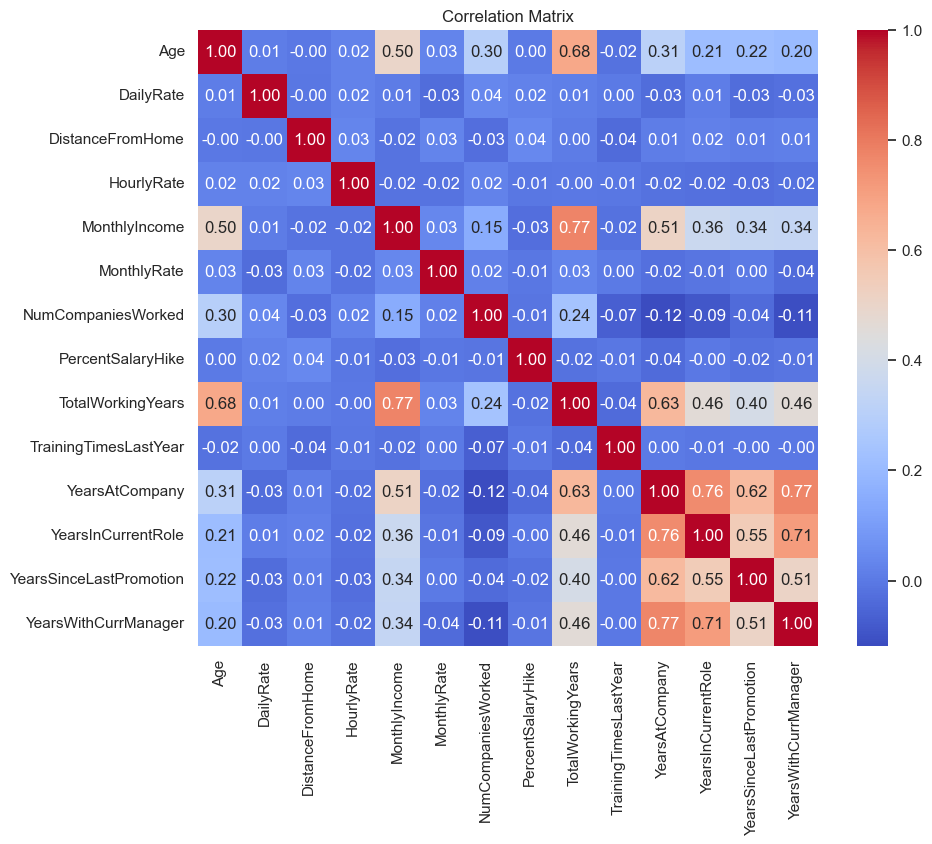

In [23]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Pairplots were plotted for the pay features to see how they related

In [24]:
rates = df[['DailyRate', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome', 'Attrition']]

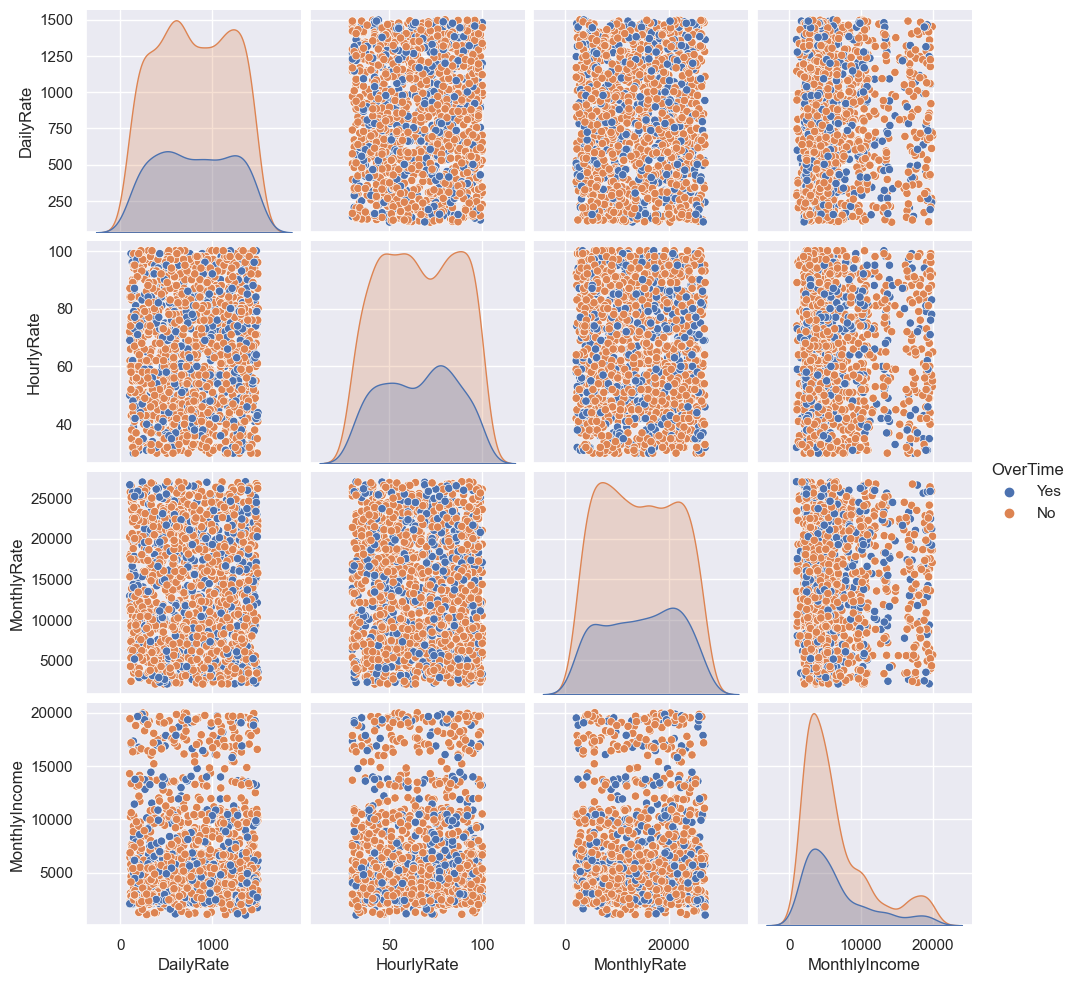

In [25]:
sns.pairplot(data=df, vars=['DailyRate', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome'], hue='OverTime')
plt.show()


# Feature Engineering & Selection

1. Converted Gender and Overtime variables, that only have two unique values, to 0 and 1.

#### Remove rate columns that have a higher range of values

1. There were 4 different features that were related to employee pay, these were also highly correlated, I dropped 3 of the 4 and kepy 'HourlyRate'
2. Converted the features with only 2 unique values to 1 and 0.
3. Bin the features related to years, those columns were the ones with many outliers
4. One hot encoding was applied to the categorical features that had more than 2 distinct values that were not columns on a scale
5. Dataset was split into test and train data

In [26]:
df.drop(['DailyRate', 'MonthlyRate', 'MonthlyIncome'], axis = 1, inplace=True)

In [27]:
df['Gender'].replace({'Female': 0, 'Male': 1},inplace=True)
df['OverTime'].replace({'No': 0, 'Yes': 1},inplace=True)
df['Attrition'].replace({'No': 0, 'Yes': 1},inplace=True)


In [28]:
df['TotalWorkingYears_bin'] = pd.cut(df['TotalWorkingYears'], bins=[0, 10, 20, 30, 40], labels=['1-10', '11-20', '21-30', '31-40'])
df['YearsAtCompany_bin'] = pd.cut(df['YearsAtCompany'], bins=[-1, 10, 20, 30, 40], labels=['1-10', '11-20', '21-30', '31-40'])
df['YearsInCurrentRole_bin'] = pd.cut(df['YearsInCurrentRole'], bins=[-1, 5, 10, 15, 20], labels=['1-5', '6-10', '11-15', '16-20'])
df['YearsSinceLastPromotion_bin'] = pd.cut(df['YearsSinceLastPromotion'], bins=[-1, 5, 10, 15], labels=['1-5', '6-10', '11-15'])
df['YearsWithCurrManager_bin'] = pd.cut(df['YearsWithCurrManager'], bins=[-1, 5, 10, 15, 20], labels=['1-5', '6-10', '11-15', '16-20'])
df.drop(['TotalWorkingYears','YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'], axis = 1, inplace = True)

In [29]:
OHE = OneHotEncoder()
SS = StandardScaler()

In [30]:
encode_cols = ['BusinessTravel', 'Department', 'EducationField', 'MaritalStatus', 'JobRole',
              'TotalWorkingYears_bin', 'YearsAtCompany_bin', 'YearsInCurrentRole_bin',
               'YearsSinceLastPromotion_bin', 'YearsWithCurrManager_bin']

one_hot_encoded_data = pd.get_dummies(df[encode_cols], columns = encode_cols, dtype=int)

df_OHE = pd.concat([df, one_hot_encoded_data], axis=1)

df_OHE.drop(columns = encode_cols, axis = 1, inplace = True)

df_OHE.head()


,Age,Attrition,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole_bin_6-10,YearsInCurrentRole_bin_11-15,YearsInCurrentRole_bin_16-20,YearsSinceLastPromotion_bin_1-5,YearsSinceLastPromotion_bin_6-10,YearsSinceLastPromotion_bin_11-15,YearsWithCurrManager_bin_1-5,YearsWithCurrManager_bin_6-10,YearsWithCurrManager_bin_11-15,YearsWithCurrManager_bin_16-20
0,41,1,1,2,1,2,0,94,3,2,...,0,0,0,1,0,0,1,0,0,0
1,49,0,8,1,2,3,1,61,2,2,...,1,0,0,1,0,0,0,1,0,0
2,37,1,2,2,4,4,1,92,2,1,...,0,0,0,1,0,0,1,0,0,0
3,33,0,3,4,5,4,0,56,3,1,...,1,0,0,1,0,0,1,0,0,0
4,27,0,2,1,7,1,1,40,3,1,...,0,0,0,1,0,0,1,0,0,0


In [31]:
scale_vars = ['Age','DistanceFromHome', 'HourlyRate','NumCompaniesWorked',
            'PercentSalaryHike', 'TrainingTimesLastYear']


df_OHE[scale_vars] = SS.fit_transform(df_OHE[scale_vars])
df_OHE.head()

,Age,Attrition,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole_bin_6-10,YearsInCurrentRole_bin_11-15,YearsInCurrentRole_bin_16-20,YearsSinceLastPromotion_bin_1-5,YearsSinceLastPromotion_bin_6-10,YearsSinceLastPromotion_bin_11-15,YearsWithCurrManager_bin_1-5,YearsWithCurrManager_bin_6-10,YearsWithCurrManager_bin_11-15,YearsWithCurrManager_bin_16-20
0,0.446350,1,-1.010909,2,1,2,0,1.383138,3,2,...,0,0,0,1,0,0,1,0,0,0
1,1.322365,0,-0.147150,1,2,3,1,-0.240677,2,2,...,1,0,0,1,0,0,0,1,0,0
2,0.008343,1,-0.887515,2,4,4,1,1.284725,2,1,...,0,0,0,1,0,0,1,0,0,0
3,-0.429664,0,-0.764121,4,5,4,0,-0.486709,3,1,...,1,0,0,1,0,0,1,0,0,0
4,-1.086676,0,-0.887515,1,7,1,1,-1.274014,3,1,...,0,0,0,1,0,0,1,0,0,0


In [32]:
X = df_OHE.drop(['Attrition'], axis=1)
y= df_OHE['Attrition']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Testing models

Four different models were fit: Logistic Regression, Random Forest, SVM, and Naive Bayes and metrics were evaluated to see which fit best on the dataset.

Results from model:  Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       240
           1       0.71      0.37      0.49        54

    accuracy                           0.86       294
   macro avg       0.79      0.67      0.70       294
weighted avg       0.84      0.86      0.84       294

Accuracy: 0.857
Precision: 0.843
Recall: 0.857
F1 Score: 0.838
F1 Score: 0.838


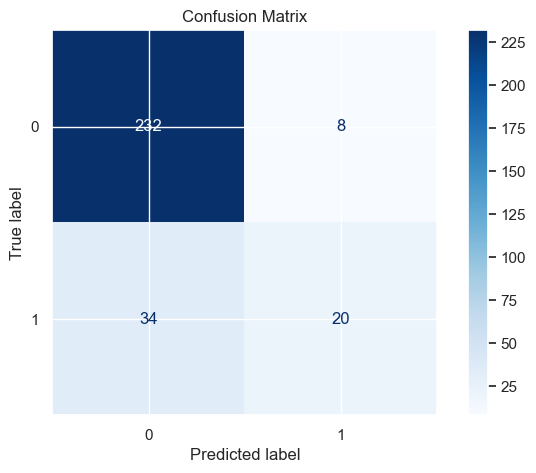



Results from model:  Random Forest
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       240
           1       0.83      0.09      0.17        54

    accuracy                           0.83       294
   macro avg       0.83      0.54      0.54       294
weighted avg       0.83      0.83      0.77       294

Accuracy: 0.830
Precision: 0.830
Recall: 0.830
F1 Score: 0.770
F1 Score: 0.770


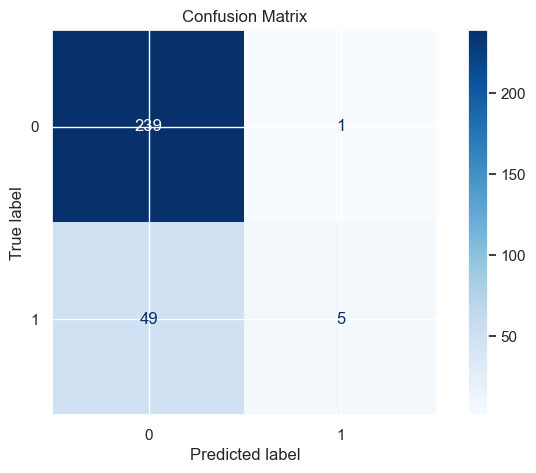



Results from model:  SVM
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       240
           1       0.00      0.00      0.00        54

    accuracy                           0.82       294
   macro avg       0.41      0.50      0.45       294
weighted avg       0.67      0.82      0.73       294

Accuracy: 0.816
Precision: 0.666
Recall: 0.816
F1 Score: 0.734
F1 Score: 0.734


C:\Users\nicol\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\metr

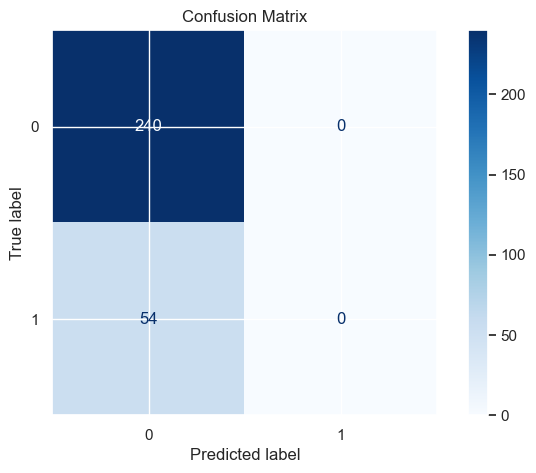



Results from model:  GaussianNB
              precision    recall  f1-score   support

           0       0.93      0.46      0.62       240
           1       0.26      0.83      0.39        54

    accuracy                           0.53       294
   macro avg       0.59      0.65      0.51       294
weighted avg       0.80      0.53      0.58       294

Accuracy: 0.531
Precision: 0.803
Recall: 0.531
F1 Score: 0.576
F1 Score: 0.576


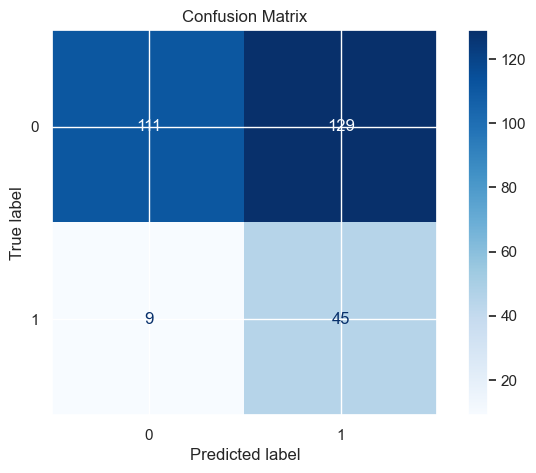

In [34]:
log_reg = LogisticRegression(max_iter=10000)
random_forest = RandomForestClassifier(n_estimators=1000)
svm = SVC(max_iter=10000)
gaussian = GaussianNB()

# List of models
models = [log_reg, random_forest, svm, gaussian]
model_names = ['Logistic Regression', 'Random Forest', 'SVM', 'GaussianNB']

# Train and evaluate models
for model, name in zip(models, model_names):
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Predict on test set
    
    print("Results from model: ", name)
    
    # Printing the classification report including metrics such as precision, recall, and F1-score
    print(classification_report(y_test, y_pred, target_names=np.unique(y).astype(str)))
    
    # Calculating additional classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    
    # Printing calculated metrics
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"F1 Score: {f1:.3f}")
    
    # Calculate and display the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    # Display the confusion matrix
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()
    
    
    print("\n")

### Decision Tree Classifier

1. A decision tree classifier was created and with metrics displayed.
2. The feature importance was determined from from the decision tree were added to a list to better visualize
3. New test and train data was created with only those features 
4. The features that were showing had an impact on attrition were identified and an logitstic regression model was modeled using only those features

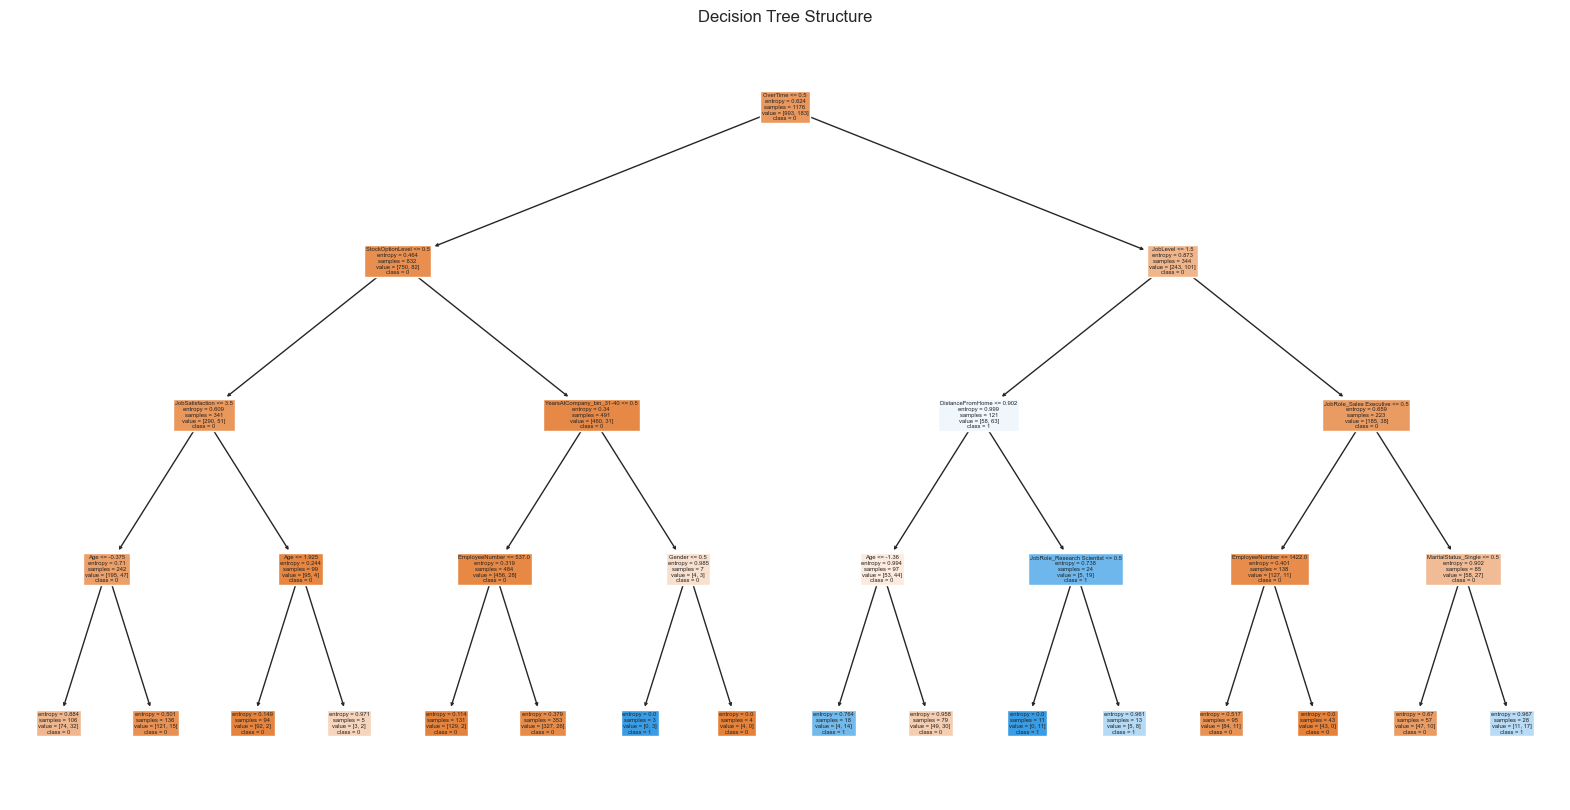

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       240
           1       0.67      0.15      0.24        54

    accuracy                           0.83       294
   macro avg       0.75      0.57      0.57       294
weighted avg       0.81      0.83      0.78       294

Accuracy: 0.830
Precision: 0.806
Recall: 0.830
F1 Score: 0.783


<Figure size 800x800 with 0 Axes>

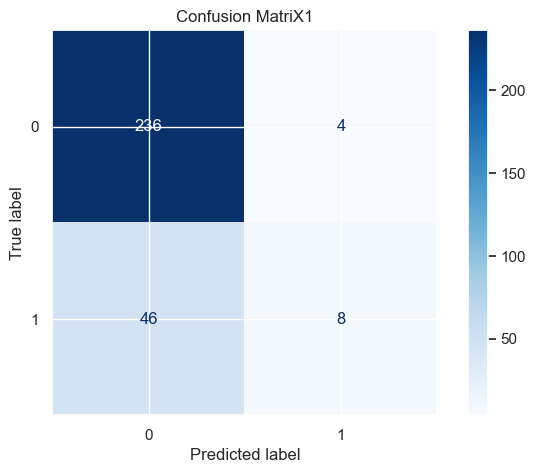

In [35]:
tree = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
tree.fit(X_train, y_train)

# Predict on the test set
y_pred = tree.predict(X_test)


# Plotting the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=X.columns.tolist(), class_names=list(np.unique(y).astype(str)))
plt.title('Decision Tree Structure')
plt.show()

# Printing the classification report including metrics such as precision, recall, and F1-score
print(classification_report(y_test, y_pred, target_names=np.unique(y).astype(str)))

# Calculating additional classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Printing calculated metrics
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

# calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plotting the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion MatriX1')
plt.show()

fi_col = []
fi = []

for i, column in enumerate(X):
    
    fi_col.append(column)
    fi.append(tree.feature_importances_[i])

In [36]:
fi_df = zip(fi_col, fi)
fi_df = pd.DataFrame(fi_df, columns=['Feature', 'Feature Importance'])
fi_df = fi_df.sort_values('Feature Importance', ascending = False).reset_index()

In [37]:
fi_df.head(20)

,index,Feature,Feature Importance
0,11,OverTime,0.248602
1,8,JobLevel,0.174200
2,0,Age,0.119442
3,40,JobRole_Sales Executive,0.079163
4,15,StockOptionLevel,0.063811
5,3,EmployeeNumber,0.062294
6,9,JobSatisfaction,0.061473
7,32,MaritalStatus_Single,0.060718
8,5,Gender,0.036738
9,1,DistanceFromHome,0.035879


In [38]:
select_columns = fi_df['Feature'][0:11]
select_columns

0                     OverTime
1                     JobLevel
2                          Age
3      JobRole_Sales Executive
4             StockOptionLevel
5               EmployeeNumber
6              JobSatisfaction
7         MaritalStatus_Single
8                       Gender
9             DistanceFromHome
10    YearsAtCompany_bin_31-40
Name: Feature, dtype: object

In [39]:
X1=df_OHE[select_columns].values
y1=df['Attrition']

In [40]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2)

Results from model: Logistic Regression 
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       241
           1       0.77      0.19      0.30        53

    accuracy                           0.84       294
   macro avg       0.81      0.59      0.61       294
weighted avg       0.83      0.84      0.80       294

Accuracy: 0.844
Precision: 0.833
Recall: 0.844
F1 Score: 0.802


C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


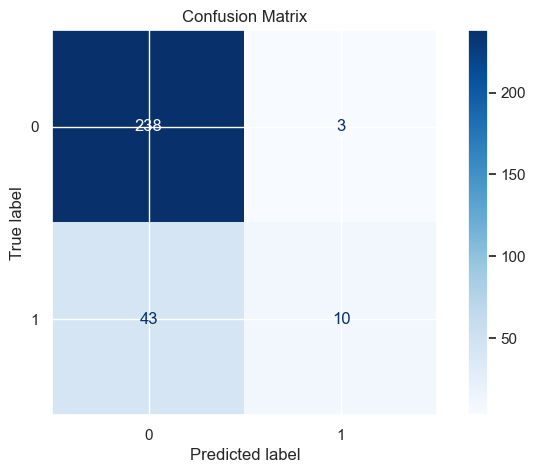

In [41]:
# Initialize models
log_reg = LogisticRegression()



# Train and evaluate models

log_reg.fit(X1_train, y1_train)  # Train model
y1_pred = log_reg.predict(X1_test)  # Predict on test set

print("Results from model: Logistic Regression ")

# Printing the classification report including metrics such as precision, recall, and F1-score
print(classification_report(y1_test, y1_pred, target_names=np.unique(y1).astype(str)))

# Calculating additional classification metrics
accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

# Printing calculated metrics
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

# Calculate and display the confusion matrix
cm = confusion_matrix(y1_test, y1_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)

# Display the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


print("\n")

In [42]:
param_grid = [    
    {'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'C' : np.logspace(-4, 4, 20),
    'solver' : ['lbfgs','newton-cg','saga'],
    'max_iter' : [100, 1000,2500, 5000]
    }
]

## Hyperparameter Tuning Logistic Regression

1. Hyperparameter tuning ws performed using gridsearch from sklearn
2. Vairous parameters were tes icluding C, penalty, max_iter, and solver
3. THe hyperparameterswere evaluated for performance using mean accuracy

In [43]:
LR = LogisticRegression()
LRparam_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    'penalty': ['l1', 'l2'],
    'max_iter': list(range(100,800,100)),
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

In [44]:
LR_search = GridSearchCV(LR, param_grid=LRparam_grid, refit = True, verbose = 3, cv=5)

# fitting the model for grid search 
LR_search.fit(X1_train , y1_train)
LR_search.best_params_
# summarize
print('Mean Accuracy: %.3f' % LR_search.best_score_)
print('Config: %s' % LR_search.best_params_)

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
[CV 1/5] END C=0.001, max_iter=100, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END C=0.001, max_iter=100, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 3/5] END C=0.001, max_iter=100, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 4/5] END C=0.001, max_iter=100, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 5/5] END C=0.001, max_iter=100, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 1/5] END C=0.001, max_iter=100, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END C=0.001, max_iter=100, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 3/5] END C=0.001, max_iter=100, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 4/5] END C=0.001, max_iter=100, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 5/5] END C=0.001, max_iter=100, penalty=l1, solver=lbfgs;, score=nan total time=   0

C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter 

[CV 2/5] END C=0.001, max_iter=100, penalty=l2, solver=saga;, score=0.847 total time=   0.0s
[CV 3/5] END C=0.001, max_iter=100, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 4/5] END C=0.001, max_iter=100, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 5/5] END C=0.001, max_iter=100, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 1/5] END C=0.001, max_iter=200, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END C=0.001, max_iter=200, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 3/5] END C=0.001, max_iter=200, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 4/5] END C=0.001, max_iter=200, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 5/5] END C=0.001, max_iter=200, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 1/5] END C=0.001, max_iter=200, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END C=0.001, max_iter=200, penalty=l1, solver=l

C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter 

[CV 1/5] END C=0.001, max_iter=200, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 2/5] END C=0.001, max_iter=200, penalty=l2, solver=saga;, score=0.847 total time=   0.0s
[CV 3/5] END C=0.001, max_iter=200, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 4/5] END C=0.001, max_iter=200, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 5/5] END C=0.001, max_iter=200, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
[CV 1/5] END C=0.001, max_iter=300, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END C=0.001, max_iter=300, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 3/5] END C=0.001, max_iter=300, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 4/5] END C=0.001, max_iter=300, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 5/5] END C=0.001, max_iter=300, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 1/5] END C=0.001, max_iter=300, penalty=l1, solver=

...

C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/5] END C=10000, max_iter=700, penalty=l2, solver=saga;, score=0.847 total time=   0.0s
[CV 3/5] END C=10000, max_iter=700, penalty=l2, solver=saga;, score=0.843 total time=   0.1s


C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\nicol\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
840 fits failed out of a total of 2800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
280 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\nicol\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score


[CV 4/5] END C=10000, max_iter=700, penalty=l2, solver=saga;, score=0.843 total time=   0.1s
[CV 5/5] END C=10000, max_iter=700, penalty=l2, solver=saga;, score=0.843 total time=   0.0s
Mean Accuracy: 0.862
Config: {'C': 10000, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}


C:\Users\nicol\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Final model
1. The hypertuned paramaters were plugged into and used to train the model and meausred against various performance metrics

In [45]:
model1 = LogisticRegression(C =1, max_iter= 100, penalty= 'l2', solver = 'newton-cg')

Results from model: Logistic Regression 
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       241
           1       0.77      0.19      0.30        53

    accuracy                           0.84       294
   macro avg       0.81      0.59      0.61       294
weighted avg       0.83      0.84      0.80       294

Accuracy: 0.844
Precision: 0.833
Recall: 0.844
F1 Score: 0.802


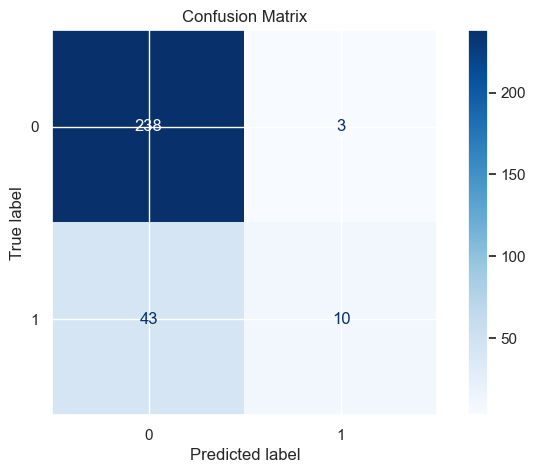

In [46]:


# Train and evaluate models

model1.fit(X1_train, y1_train)  # Train model
y1_pred = model1.predict(X1_test)  # Predict on test set

print("Results from model: Logistic Regression ")

# Printing the classification report including metrics such as precision, recall, and F1-score
print(classification_report(y1_test, y1_pred, target_names=np.unique(y1).astype(str)))

# Calculating additional classification metrics
accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, average='weighted')
recall = recall_score(y1_test, y1_pred, average='weighted')
f1 = f1_score(y1_test, y1_pred, average='weighted')

# Printing calculated metrics
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

# Calculate and display the confusion matrix
cm = confusion_matrix(y1_test, y1_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)

# Display the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()



## Cross Validation

Cross validation score from sklearn was used to evaluate model performance on the logistic regression model with just the transofrmed data used and then again on the dataset using the selected features.


In [47]:
from sklearn.model_selection import cross_val_score

In [48]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

In [49]:
print(f"cross-Validation accuracy: {scores.mean()}")

cross-Validation accuracy: 0.49591836734693884


In [50]:
scores1 = cross_val_score(model1, X1, y1, cv=5, scoring='accuracy')

In [51]:
print(f"cross-Validation accuracy: {scores1.mean()}")

cross-Validation accuracy: 0.8585034013605443


# Conclusion

While the model that was used throughout the project, logistic regression, performed decently, the model and dataset could be evaulated further to provide better results.

Th EDA and decsion tree steps both showed similar results as far as factors that lead to attrition. Both overtime and employees that had a job or role related to sales were more likely to lead to attrtion. This would be a good place to start digging into to determine what specifically about the sales roles or overtime requirements are causing people to leave.

Finally, the corss validation showed that 

# Future Work

There are things that I would like to look at in the future to improve the performance of the models:
1. Feature SElection: improvements could be made on the model and going ack through and selecting different features or trying diffrerent PCA evaluations could improve the model.
    - Specifically features pertaining to years and rates could be engineererd differently to evaluate which provides the best information to the model.
2. Different models: Digging deeper into different classification models to see if they would preform better after better or more thorough feature selection is performed
2. Compare the work I did with available code from others attempts at the same problem to see if anything could be applied to my model to improve it.